# Feature Reduction, Selection and Factor Analysis in Python

## 1. Libraries and setup

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression, LassoCV, RidgeCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.metrics import accuracy_score, roc_auc_score

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)

## 2. Simple example: useful, redundant, and noisy features

In [3]:
n = 250
value = rng.normal(size=n)
engagement = rng.normal(size=n)
simple_df = pd.DataFrame({
    "income_index": 60 + 12*value + rng.normal(0,3,n),
    "account_balance_index": 55 + 10*value + rng.normal(0,4,n),
    "income_index_duplicate": 60 + 12*value + rng.normal(0,1,n),
    "website_visits": 30 + 8*engagement + rng.normal(0,4,n),
    "app_sessions": 20 + 7*engagement + rng.normal(0,3,n),
    "near_constant_flag": rng.choice([0,1], n, p=[.98,.02]),
    "random_noise": rng.normal(size=n),
})
score = .9*value + .7*engagement + rng.normal(0,.7,n)
simple_df["target_purchase"] = (score > np.median(score)).astype(int)
simple_df.head()

,income_index,account_balance_index,income_index_duplicate,website_visits,app_sessions,near_constant_flag,random_noise,target_purchase
0,67.748192,58.092976,63.597322,30.923205,15.723373,0,-0.530822,0
1,50.205746,43.403100,46.790904,38.799615,20.517079,0,2.214153,1
2,66.846974,58.444240,68.590941,40.641937,36.076324,0,-0.451951,1
3,66.779266,72.600670,71.920687,23.313026,14.082870,0,-0.665878,1
4,27.693991,42.630322,36.590571,25.136211,17.647854,0,0.434010,0


### 2.1 Data quality and variance check

Low-variance features often add little information. This is a fast filter, not a final modeling decision.

In [4]:
feature_cols = simple_df.drop(columns="target_purchase").columns
quality_table = pd.DataFrame({
    "dtype": simple_df.dtypes,
    "missing_values": simple_df.isna().sum(),
    "unique_values": simple_df.nunique(),
})
quality_table

,dtype,missing_values,unique_values
income_index,float64,0,250
account_balance_index,float64,0,250
income_index_duplicate,float64,0,250
website_visits,float64,0,250
app_sessions,float64,0,250
near_constant_flag,int64,0,2
random_noise,float64,0,250
target_purchase,int64,0,2


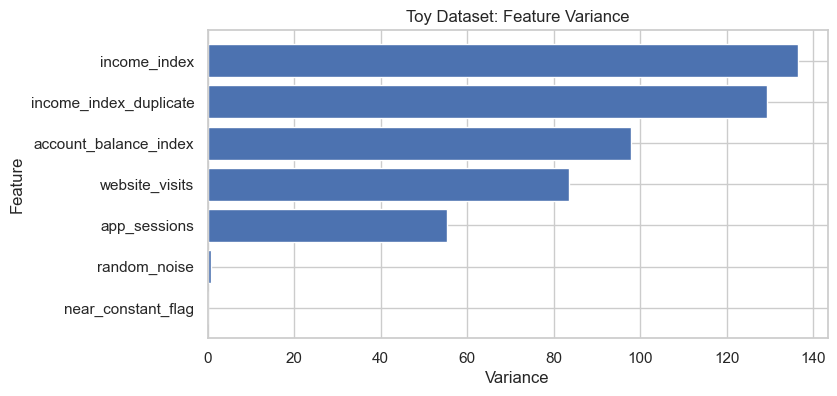

In [5]:
variance_table = simple_df[feature_cols].var().sort_values(ascending=True)
plt.figure(figsize=(8,4))
plt.barh(variance_table.index, variance_table.values)
plt.title("Toy Dataset: Feature Variance")
plt.xlabel("Variance")
plt.ylabel("Feature")
plt.show()

In [6]:
X_simple = simple_df.drop(columns="target_purchase")
y_simple = simple_df["target_purchase"]
vt = VarianceThreshold(threshold=0.05).fit(X_simple)
pd.DataFrame({"feature": X_simple.columns, "variance": X_simple.var().values, "kept": vt.get_support()})

,feature,variance,kept
0,income_index,136.415271,True
1,account_balance_index,97.862226,True
2,income_index_duplicate,129.213786,True
3,website_visits,83.522489,True
4,app_sessions,55.342298,True
5,near_constant_flag,0.023518,False
6,random_noise,0.895798,True


### 2.2 Correlation-based redundancy check

Highly correlated features may carry overlapping information. Do not remove features automatically; first consider business meaning, reliability, and relationship with the target.

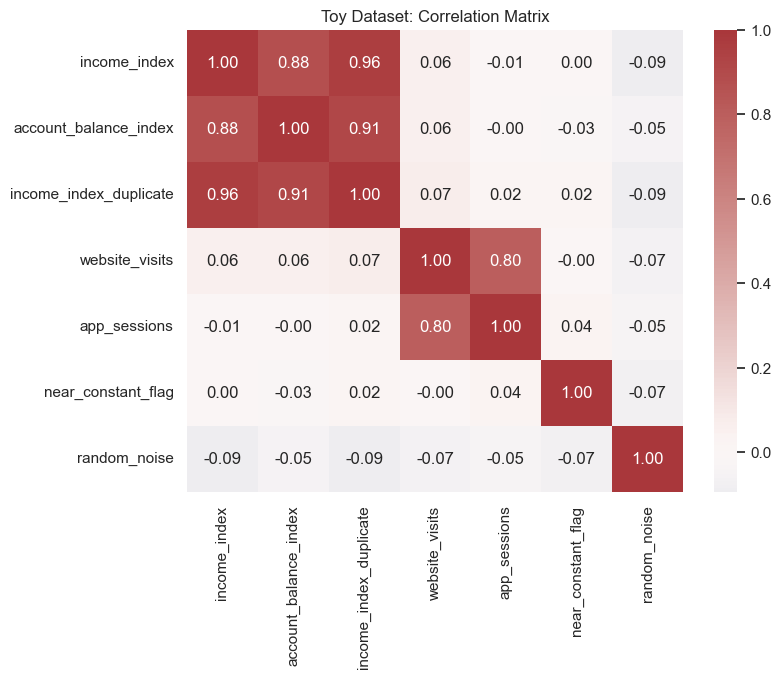

In [7]:
plt.figure(figsize=(8,6))
sns.heatmap(X_simple.corr(), annot=True, cmap="vlag", center=0, fmt=".2f")
plt.title("Toy Dataset: Correlation Matrix")
plt.show()

### 2.3 Filter method: ANOVA-style feature scoring

For numeric predictors and a categorical target, ANOVA F-scores rank features by how differently they behave across target classes.

In [8]:
skb = SelectKBest(score_func=f_classif, k="all").fit(X_simple, y_simple)
anova_scores = pd.DataFrame({"feature": X_simple.columns, "f_score": skb.scores_, "p_value": skb.pvalues_}).sort_values("f_score", ascending=False)
anova_scores

,feature,f_score,p_value
2,income_index_duplicate,105.544039,7.375685e-21
0,income_index,90.217505,1.897893e-18
1,account_balance_index,67.957549,9.769940e-15
4,app_sessions,61.892688,1.119856e-13
3,website_visits,50.219285,1.420669e-11
6,random_noise,4.995048,2.631097e-02
5,near_constant_flag,0.679452,4.105675e-01


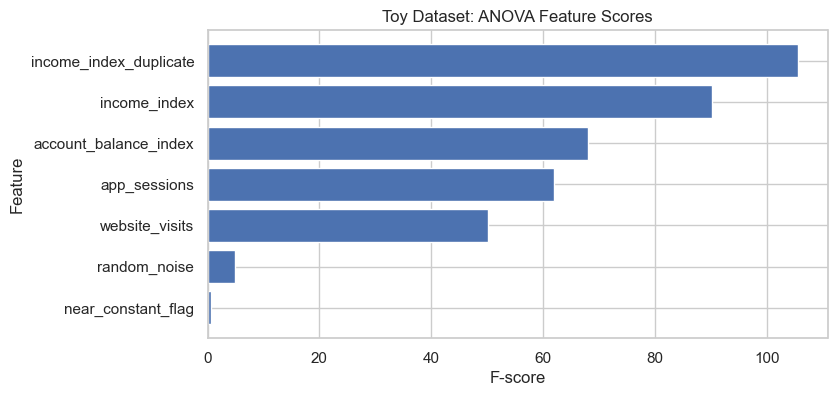

In [9]:
plt.figure(figsize=(8,4))
plt.barh(anova_scores["feature"], anova_scores["f_score"])
plt.gca().invert_yaxis()
plt.title("Toy Dataset: ANOVA Feature Scores")
plt.xlabel("F-score")
plt.ylabel("Feature")
plt.show()

## 3. Realistic dataset: Wine classification

The Wine dataset contains chemical measurements with different scales, making it suitable for feature selection and PCA.

In [10]:
wine = load_wine(as_frame=True)
wine_df = wine.frame.copy()
X = wine_df.drop(columns="target")
y = wine_df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.30, stratify=y, random_state=RANDOM_STATE)
wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


### 3.1 Baseline model with all features

The baseline helps judge whether a smaller feature set keeps enough predictive performance.

In [11]:
baseline = Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=3000))])
baseline.fit(X_train, y_train)
baseline_acc = accuracy_score(y_test, baseline.predict(X_test))
print(f"Baseline accuracy with all {X.shape[1]} features: {baseline_acc:.3f}")

Baseline accuracy with all 13 features: 0.981


## 4. Filter method on Wine: SelectKBest

In [12]:
k = 6
filter_model = Pipeline([("scaler", StandardScaler()), ("select", SelectKBest(f_classif, k=k)), ("model", LogisticRegression(max_iter=3000))])
filter_model.fit(X_train, y_train)
filter_acc = accuracy_score(y_test, filter_model.predict(X_test))
filter_features = X.columns[filter_model.named_steps["select"].get_support()].tolist()
print(f"Filter model accuracy with {k} features: {filter_acc:.3f}")
print(filter_features)

Filter model accuracy with 6 features: 1.000
['alcohol', 'flavanoids', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


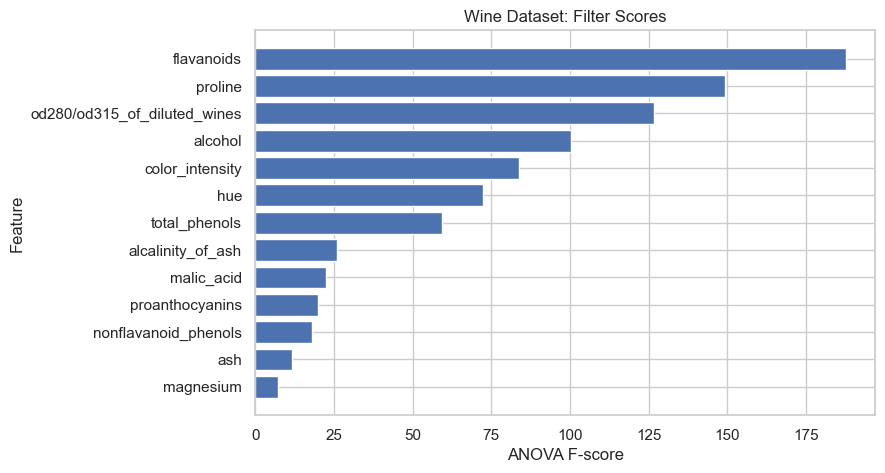

In [13]:
filter_scores = pd.DataFrame({"feature": X.columns, "f_score": filter_model.named_steps["select"].scores_}).sort_values("f_score", ascending=False)
plt.figure(figsize=(8,5))
plt.barh(filter_scores["feature"], filter_scores["f_score"])
plt.gca().invert_yaxis()
plt.title("Wine Dataset: Filter Scores")
plt.xlabel("ANOVA F-score")
plt.ylabel("Feature")
plt.show()

## 5. Wrapper methods

Wrapper methods evaluate feature subsets using a predictive model. They are more model-aware than filters, but more computationally expensive.

In [14]:
rfe = Pipeline([("scaler", StandardScaler()), ("rfe", RFE(LogisticRegression(max_iter=3000), n_features_to_select=6)), ("model", LogisticRegression(max_iter=3000))])
rfe.fit(X_train, y_train)
rfe_acc = accuracy_score(y_test, rfe.predict(X_test))
rfe_features = X.columns[rfe.named_steps["rfe"].support_].tolist()
print(f"RFE accuracy: {rfe_acc:.3f}")
print(rfe_features)

RFE accuracy: 1.000
['alcohol', 'flavanoids', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


Forward and backward selection follow the same wrapper logic: repeatedly add or remove variables and evaluate model performance. RFE is implemented here as the practical wrapper example because it is efficient and easy to inspect.

## 6. Embedded methods

Embedded methods perform feature evaluation during model training. LASSO, Ridge, and tree-based feature importance are common examples.

In [15]:
X_train_scaled = StandardScaler().fit_transform(X_train)
y_train_binary = (y_train == 0).astype(int)
lasso = LassoCV(cv=3, random_state=RANDOM_STATE, max_iter=10000).fit(X_train_scaled, y_train_binary)
lasso_result = pd.DataFrame({"feature": X.columns, "coefficient": lasso.coef_, "selected_non_zero": np.abs(lasso.coef_) > 1e-6}).sort_values("coefficient", key=lambda s: abs(s), ascending=False)
print(f"LASSO alpha: {lasso.alpha_:.5f}")
lasso_result

LASSO alpha: 0.00686


,feature,coefficient,selected_non_zero
12,proline,0.190227,True
6,flavanoids,0.147428,True
3,alcalinity_of_ash,-0.108298,True
0,alcohol,0.088778,True
2,ash,0.067343,True
11,od280/od315_of_diluted_wines,0.048587,True
8,proanthocyanins,-0.046693,True
1,malic_acid,0.013684,True
4,magnesium,0.000189,True
7,nonflavanoid_phenols,0.000000,False


In [16]:
ridge = RidgeCV(alphas=np.logspace(-3,3,15), cv=3).fit(X_train_scaled, y_train_binary)
ridge_result = pd.DataFrame({"feature": X.columns, "coefficient": ridge.coef_}).sort_values("coefficient", key=lambda s: abs(s), ascending=False)
print(f"Ridge alpha: {ridge.alpha_:.5f}")
ridge_result.head(10)

Ridge alpha: 7.19686


,feature,coefficient
12,proline,0.177431
6,flavanoids,0.148863
3,alcalinity_of_ash,-0.116202
0,alcohol,0.097395
2,ash,0.070751
11,od280/od315_of_diluted_wines,0.064299
8,proanthocyanins,-0.052883
1,malic_acid,0.018409
4,magnesium,0.014608
7,nonflavanoid_phenols,0.011830


In [17]:
rf = RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))
rf_importance = pd.DataFrame({"feature": X.columns, "importance": rf.feature_importances_}).sort_values("importance", ascending=False)
print(f"Random Forest accuracy: {rf_acc:.3f}")
rf_importance

Random Forest accuracy: 1.000


,feature,importance
6,flavanoids,0.177677
0,alcohol,0.155654
9,color_intensity,0.134549
10,hue,0.133527
11,od280/od315_of_diluted_wines,0.103641
12,proline,0.098419
4,magnesium,0.052765
1,malic_acid,0.041216
5,total_phenols,0.037174
3,alcalinity_of_ash,0.022999


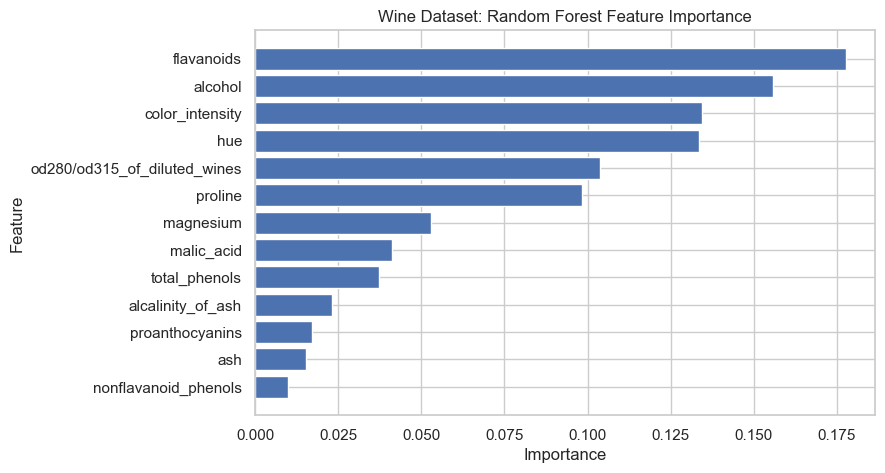

In [18]:
plt.figure(figsize=(8,5))
plt.barh(rf_importance["feature"], rf_importance["importance"])
plt.gca().invert_yaxis()
plt.title("Wine Dataset: Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 7. Boruta-style shadow feature check

Boruta compares original features with randomized shadow features. A feature that beats the strongest shadow feature is a strong candidate. This is a simplified version.

In [19]:
X_shadow = X_train.copy()
for col in X_train.columns:
    X_shadow[f"shadow_{col}"] = rng.permutation(X_train[col].values)
rf_shadow = RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1).fit(X_shadow, y_train)
imp = pd.DataFrame({"feature": X_shadow.columns, "importance": rf_shadow.feature_importances_})
shadow_max = imp.loc[imp.feature.str.startswith("shadow_"), "importance"].max()
boruta_simple = imp[~imp.feature.str.startswith("shadow_")].copy()
boruta_simple["decision"] = np.where(boruta_simple["importance"] > shadow_max, "confirmed", "tentative_or_rejected")
boruta_simple.sort_values("importance", ascending=False)

,feature,importance,decision
12,proline,0.192067,confirmed
6,flavanoids,0.133495,confirmed
9,color_intensity,0.123082,confirmed
11,od280/od315_of_diluted_wines,0.107328,confirmed
0,alcohol,0.089190,confirmed
10,hue,0.083400,confirmed
5,total_phenols,0.053621,confirmed
1,malic_acid,0.051722,confirmed
3,alcalinity_of_ash,0.031941,confirmed
4,magnesium,0.025811,confirmed


## 8. PCA for feature reduction

PCA creates new components from the original variables. It is feature reduction, not feature selection, because the model no longer uses the original variables directly.

In [20]:
X_scaled = StandardScaler().fit_transform(X)
pca = PCA().fit(X_scaled)
explained = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_)
})
explained.head(10)

,component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.361988,0.361988
1,PC2,0.192075,0.554063
2,PC3,0.111236,0.665300
3,PC4,0.070690,0.735990
4,PC5,0.065633,0.801623
5,PC6,0.049358,0.850981
6,PC7,0.042387,0.893368
7,PC8,0.026807,0.920175
8,PC9,0.022222,0.942397
9,PC10,0.019300,0.961697


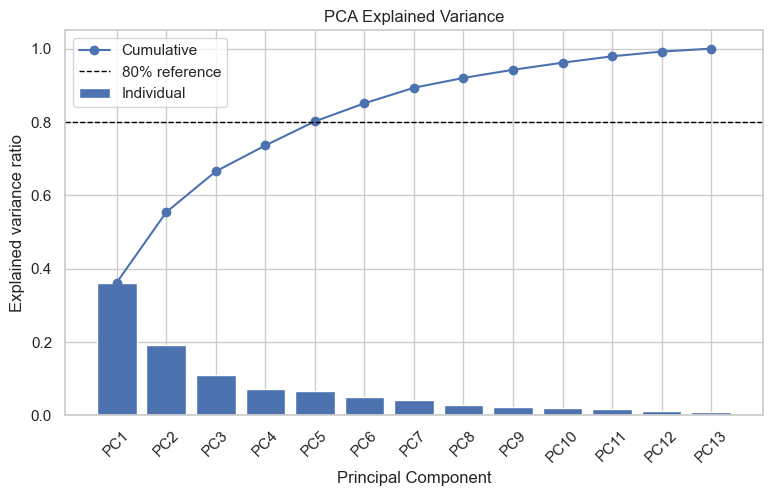

In [21]:
plt.figure(figsize=(9,5))
plt.bar(explained["component"], explained["explained_variance_ratio"], label="Individual")
plt.plot(explained["component"], explained["cumulative_explained_variance"], marker="o", label="Cumulative")
plt.axhline(.80, linestyle="--", color="black", linewidth=1, label="80% reference")
plt.xticks(rotation=45)
plt.title("PCA Explained Variance")
plt.xlabel("Principal Component")
plt.ylabel("Explained variance ratio")
plt.legend()
plt.show()

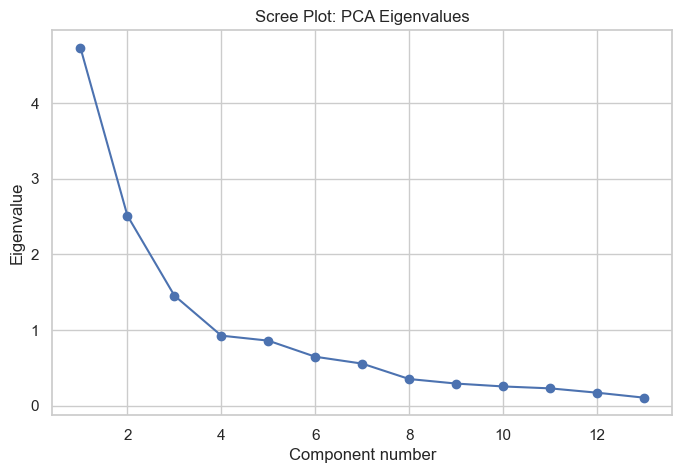

In [22]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca.explained_variance_) + 1), pca.explained_variance_, marker="o")
plt.title("Scree Plot: PCA Eigenvalues")
plt.xlabel("Component number")
plt.ylabel("Eigenvalue")
plt.show()

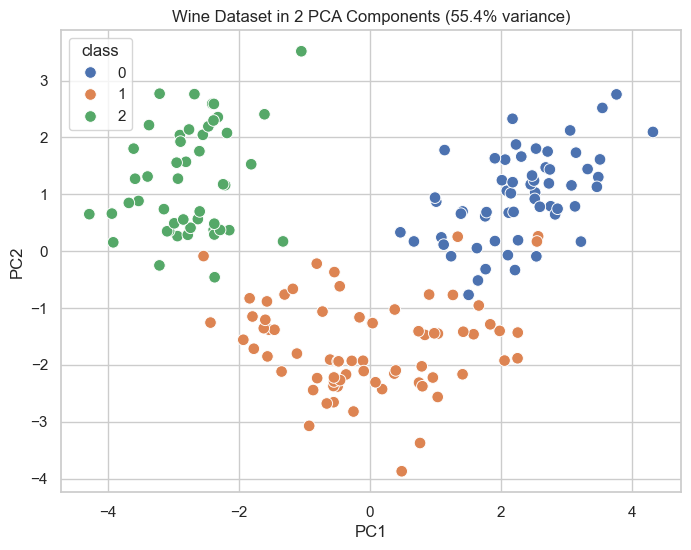

In [23]:
pca2 = PCA(n_components=2)
components = pca2.fit_transform(X_scaled)
pca_plot = pd.DataFrame({"PC1": components[:,0], "PC2": components[:,1], "class": y.astype(str)})
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_plot, x="PC1", y="PC2", hue="class", s=70)
plt.title(f"Wine Dataset in 2 PCA Components ({pca2.explained_variance_ratio_.sum():.1%} variance)")
plt.show()

In [24]:
loadings = pd.DataFrame(pca2.components_.T, columns=["PC1_loading", "PC2_loading"], index=X.columns)
loadings.sort_values("PC1_loading", key=lambda s: abs(s), ascending=False).head(10)

,PC1_loading,PC2_loading
flavanoids,0.422934,-0.003360
total_phenols,0.394661,0.065040
od280/od315_of_diluted_wines,0.376167,-0.164496
proanthocyanins,0.313429,0.039302
nonflavanoid_phenols,-0.298533,0.028779
hue,0.296715,-0.279235
proline,0.286752,0.364903
malic_acid,-0.245188,0.224931
alcalinity_of_ash,-0.239320,-0.010591
alcohol,0.144329,0.483652


In [25]:
pca_model = Pipeline([("scaler", StandardScaler()), ("pca", PCA(n_components=.90)), ("model", LogisticRegression(max_iter=3000))])
pca_model.fit(X_train, y_train)
pca_acc = accuracy_score(y_test, pca_model.predict(X_test))
print(f"PCA model accuracy: {pca_acc:.3f}")
print(f"Components used for 90% variance: {pca_model.named_steps['pca'].n_components_}")

PCA model accuracy: 0.963
Components used for 90% variance: 7


## 9. Factor Analysis

Factor Analysis estimates latent factors behind observed variables. It is useful when several measured variables may reflect shared underlying concepts.

In [32]:
synthetic_path = Path("data/feature_reduction_selection_factor_analysis_synthetic.csv")
synthetic_df = pd.read_csv(synthetic_path)
synthetic_df.head()

,income_index,account_balance_index,premium_product_count,website_visits,app_sessions,email_click_rate,discount_usage_rate,price_comparison_visits,complaint_count,tenure_months,income_index_duplicate,near_constant_flag,random_noise_1,random_noise_2,premium_service_purchase
0,61.957720,56.239367,2.606091,45.906989,28.816451,0.316705,0.234549,9.187683,1,14,63.204165,0,-0.577147,-0.072857,1
1,45.646381,41.936648,1.213362,39.912249,30.232703,0.298471,0.270496,5.754594,0,72,48.612097,0,-0.898440,-0.266585,1
2,72.980855,64.240551,3.280607,32.108668,16.871168,0.150641,0.206246,6.534315,1,7,68.246429,0,1.442530,-0.513813,0
3,72.277646,65.413065,3.137180,11.788641,5.911025,0.146965,0.395269,14.026518,1,55,72.064711,1,-0.869408,-0.439723,0
4,35.952376,29.870482,0.974703,5.222329,-0.267128,0.005731,0.272258,10.484259,1,64,36.197372,0,0.562300,1.112015,0


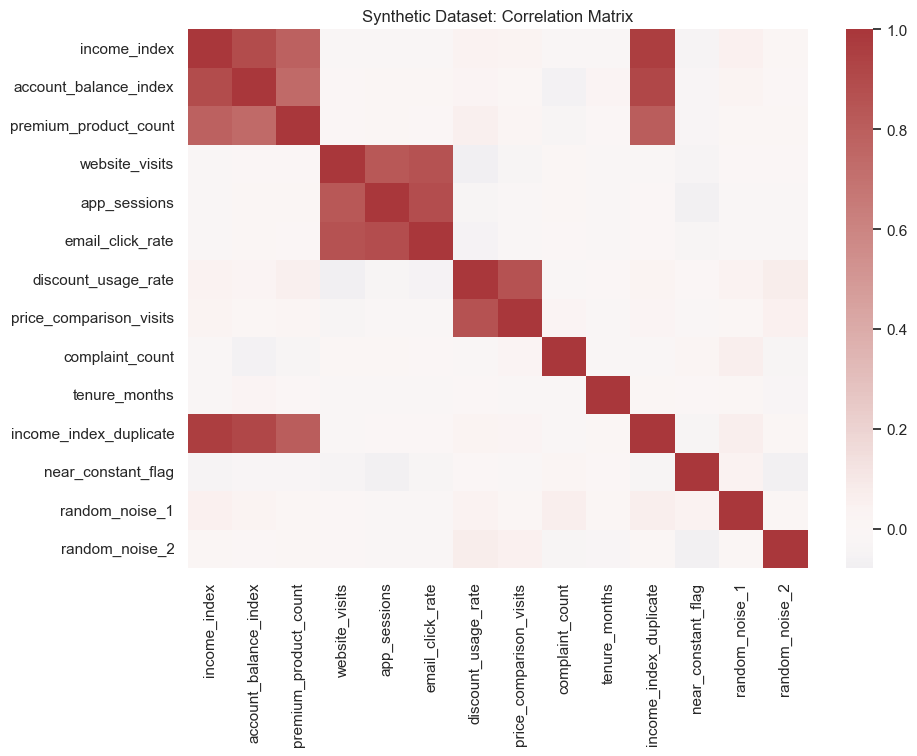

In [33]:
numeric_features = synthetic_df.select_dtypes(include=np.number).drop(columns="premium_service_purchase").columns
X_factor = synthetic_df[numeric_features]
X_factor_scaled = StandardScaler().fit_transform(X_factor)
plt.figure(figsize=(10,7))
sns.heatmap(pd.DataFrame(X_factor_scaled, columns=numeric_features).corr(), cmap="vlag", center=0)
plt.title("Synthetic Dataset: Correlation Matrix")
plt.show()

In [34]:
fa = FactorAnalysis(n_components=3, random_state=RANDOM_STATE)
factor_scores = fa.fit_transform(X_factor_scaled)
factor_loadings = pd.DataFrame(fa.components_.T, index=numeric_features, columns=["Factor_1", "Factor_2", "Factor_3"])
factor_loadings

,Factor_1,Factor_2,Factor_3
income_index,0.967991,0.013987,0.001604
account_balance_index,0.923844,-0.016588,0.013875
premium_product_count,0.810981,-0.008582,-0.011490
website_visits,-0.021807,-0.900020,-0.058125
app_sessions,-0.009847,-0.921760,-0.096328
email_click_rate,-0.006411,-0.947904,-0.087572
discount_usage_rate,0.043966,0.143736,-0.927705
price_comparison_visits,0.038125,0.110250,-0.912237
complaint_count,-0.030045,-0.004867,0.001039
tenure_months,0.005797,0.017745,0.017987


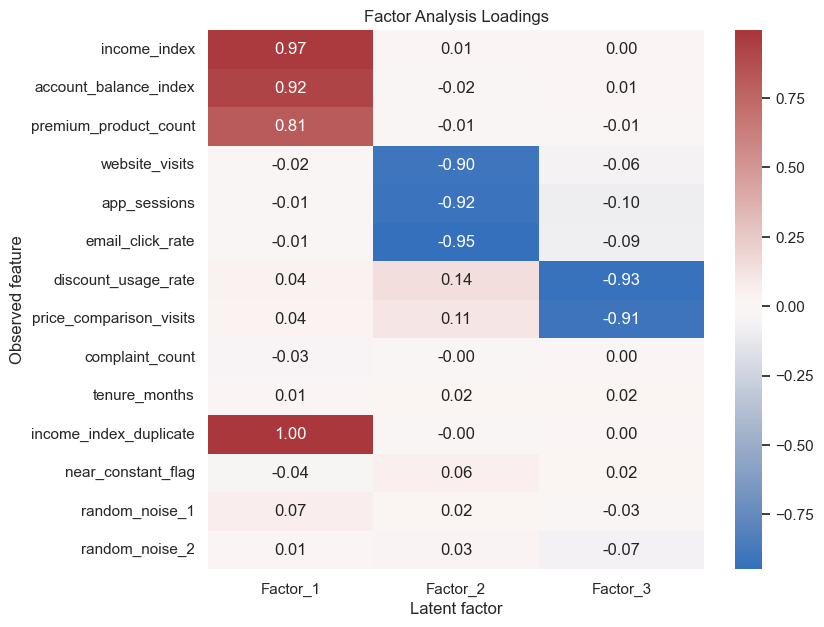

In [35]:
plt.figure(figsize=(8,7))
sns.heatmap(factor_loadings, annot=True, cmap="vlag", center=0, fmt=".2f")
plt.title("Factor Analysis Loadings")
plt.xlabel("Latent factor")
plt.ylabel("Observed feature")
plt.show()

**Interpretation.** Variables with strong loadings on the same factor may represent a common hidden driver. The factor name is not given by the algorithm; it is assigned based on the loading pattern.

## 10. Method comparison summary

In [36]:
comparison = pd.DataFrame({
    "method": ["All features", "Filter: SelectKBest", "Wrapper: RFE", "Embedded: Random Forest", "PCA 90% variance"],
    "features_or_components": [X.shape[1], len(filter_features), len(rfe_features), X.shape[1], pca_model.named_steps["pca"].n_components_],
    "test_accuracy": [baseline_acc, filter_acc, rfe_acc, rf_acc, pca_acc]
})
comparison

,method,features_or_components,test_accuracy
0,All features,13,0.981481
1,Filter: SelectKBest,6,1.000000
2,Wrapper: RFE,6,1.000000
3,Embedded: Random Forest,13,1.000000
4,PCA 90% variance,7,0.962963


## 11. Common mistakes and pitfalls

- Selecting features before splitting data can cause leakage. Fit selectors only on the training data.
- PCA should normally be applied after scaling.
- PCA components are synthetic and should not be interpreted like original business variables.
- Correlation does not prove that one feature is useless.
- Wrapper methods can be computationally expensive and can overfit the feature search.
- Filter methods are fast, but they may miss feature interactions.
- Feature importance values can differ by model type, preprocessing, and random seed.